<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Pr%C3%A1ctica_21_Regresi%C3%B3n_Lineal_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva
## Práctica: Regresión Lineal Simple con Scikit-Learn
---


## Datos del Estudiante

*   Marco Antonio Muñoz Quiroz
*   Matrícula: 261540

---

## Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar la regresión lineal simple utilizando Scikit-Learn para modelar la relación entre dos variables numéricas**, verificar los principales supuestos del modelo (linealidad, normalidad de residuos y homocedasticidad), **interpretar los coeficientes del modelo**, calcular e interpretar la **correlación entre variables** y evaluar el desempeño del modelo mediante métricas como el MSE, RMSE y R².


Trabajarás con el archivo restaurantes.csv, que contiene dos columnas:

- `poblation`: población de la ciudad (variable independiente). Tiene valores decimales mayores que cero. Estos valores representan la población de la ciudad multiplicada por 10,000. Por ejemplo, 6.1101 significa que la población de esa ciudad es 61,101.

- `profit`: ganancia del restaurante en esa ciudad (variable dependiente). Tiene valores decimales, algunos negativos y otros positivos. Estos representan las ganancias mensuales promedio de su restaurante en cada ciudad, en unidades de $10,000. Por ejemplo, 17.592 representa 175,920 en ganancias mensuales promedio para esa ciudad. -2.6807 representa -26,807 en pérdidas mensuales promedio para esa ciudad.





## 🔧 Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `restaurantes.csv`
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente el conjunto de datos.

In [118]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
def titulo(texto):
    linea = "=" * (len(texto) + 6)
    print("\n" + linea)
    print(f" {texto.upper()} ")
    print(linea + "\n")

In [120]:
# Importo libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import fill
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro
from scipy.stats import linregress, spearmanr
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [121]:
# Ajusto visualización para leer mejor las tablas
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)

# Cargo el CSV
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Semana10/Practica 21/restaurantes.csv")

# Aseguro tipos numéricos
df["poblation"] = df["poblation"].astype(float)
df["profit"] = df["profit"].astype(float)

# Muestro primeras filas
print("Primeras 10 filas:")
print(df.head(10))

# Describo estadísticamente
print("\nDescripción básica:")
print(df.describe())


Primeras 10 filas:
   poblation   profit
0     6.1101  17.5920
1     5.5277   9.1302
2     8.5186  13.6620
3     7.0032  11.8540
4     5.8598   6.8233
5     8.3829  11.8860
6     7.4764   4.3483
7     8.5781  12.0000
8     6.4862   6.5987
9     5.0546   3.8166

Descripción básica:
       poblation   profit
count    97.0000  97.0000
mean      8.1598   5.8391
std       3.8699   5.5103
min       5.0269  -2.6807
25%       5.7077   1.9869
50%       6.5894   4.5623
75%       8.5781   7.0467
max      22.2030  24.1470


##  Parte 2: Análisis exploratorio y relación entre variables

### 2.1 Diagrama de Dispersión
1. Grafica un **diagrama de dispersión** entre `poblation` y `profit`
2. Responde:  
**¿La relación entre las variables parece lineal? ¿Por qué?**

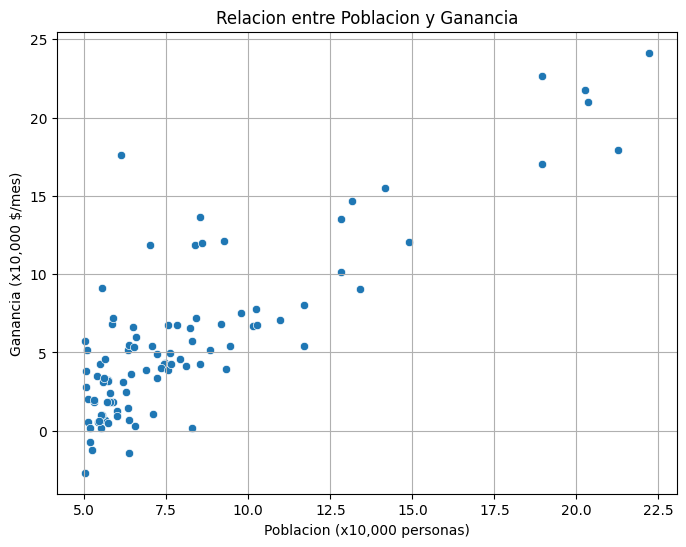


 ANALISIS DEL DIAGRAMA DE DISPERSION 

A simple vista, los puntos muestran una tendencia ascendente: a mayor poblacion, las
ganancias tienden a ser mas altas. 

La nube de puntos se alinea de forma aproximada a una recta con pendiente positiva, sin
curvaturas evidentes. 



In [122]:
# graficamos la relacion entre poblation y profit
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="poblation", y="profit")
plt.title("Relacion entre Poblacion y Ganancia")
plt.xlabel("Poblacion (x10,000 personas)")
plt.ylabel("Ganancia (x10,000 $/mes)")
plt.grid(True)
plt.show()

# imprimimos conclusiones basadas solo en la inspeccion visual
ancho = 90
titulo("Analisis del diagrama de dispersion")
print(fill("A simple vista, los puntos muestran una tendencia ascendente: a mayor poblacion, "
           "las ganancias tienden a ser mas altas.", width=ancho), "\n")
print(fill("La nube de puntos se alinea de forma aproximada a una recta con pendiente positiva, "
           "sin curvaturas evidentes.", width=ancho), "\n")

### 2.2: Cálculo e interpretación de la correlación
1. Calcula e imprime el **coeficiente de correlación de Pearson** entre `poblation` y `profit`
2. Interpreta el resultado:
- ¿Qué tan fuerte es la relación?
- ¿Es positiva o negativa?
- ¿Es coherente con el gráfico anterior?

In [123]:
# calculamos la correlacion de pearson entre poblation y profit
r = df["poblation"].corr(df["profit"])

print("**Correlacion de Pearson**\n")
print(f"Valor de r: {r:.3f}\n")

print("¿Qué tan fuerte es la relación?")
print("El valor de r se acerca a 1, lo que indica una relacion fuerte entre la poblacion "
      "y la ganancia.\n")

print("¿Es positiva o negativa?")
print("El valor de r es positivo, lo que significa que conforme aumenta la poblacion, "
      "las ganancias tambien tienden a aumentar.\n")

print("¿Es coherente con el gráfico anterior?")
print("La relacion positiva coincide con lo que se observa en el grafico: los puntos "
      "siguen una tendencia ascendente, lo que refuerza la idea de una relacion lineal positiva.")


**Correlacion de Pearson**

Valor de r: 0.838

¿Qué tan fuerte es la relación?
El valor de r se acerca a 1, lo que indica una relacion fuerte entre la poblacion y la ganancia.

¿Es positiva o negativa?
El valor de r es positivo, lo que significa que conforme aumenta la poblacion, las ganancias tambien tienden a aumentar.

¿Es coherente con el gráfico anterior?
La relacion positiva coincide con lo que se observa en el grafico: los puntos siguen una tendencia ascendente, lo que refuerza la idea de una relacion lineal positiva.


## Parte 3: Construcción del modelo, coeficientes y visualización

###3.1 Construcción del modelo - obtención de los parámetros y coeficientes
1. Construye un modelo de regresión lineal simple usando las bibliotecas de Scikit-Learn
2. Imprime el intercepto y el coeficiente de la regresión (pendiente)
3. Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?
4. Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?

In [124]:

# construimos el modelo de regresion lineal simple
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values
modelo = LinearRegression().fit(X, y)

# obtenemos parametros del modelo
intercepto = modelo.intercept_
pendiente = float(modelo.coef_[0])

# 1) Intercepto y coeficiente (pendiente)
print("**Imprime el intercepto y el coeficiente de la regresión (pendiente)**\n")
print(f"Intercepto (beta_0): {intercepto:.4f} ")
print(f"Coeficiente/Pendiente (beta_1): {pendiente:.4f} \n")

# calculos auxiliares para interpretar en dinero real
intercepto_dolares = intercepto * 10000
pendiente_dolares_por_10kpersonas = pendiente * 10000
pendiente_dolares_por_persona = pendiente_dolares_por_10kpersonas / 10000

# obtenemos parametros
beta0 = modelo.intercept_
beta1 = float(modelo.coef_[0])

# construimos la ecuacion de regresion
# profit_hat = beta0 + beta1 * poblation
ecuacion = f"profit_hat = {beta0:.4f} + {beta1:.4f} * poblation"

# 2) Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?
print("**Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?**\n")
print(fill(
    f"Cuando la poblacion es 0, el modelo: \n"
    f"{ecuacion} "
    f"estima una ganancia promedio de "
    f"{intercepto:.4f} unidades de 10,000 $/mes, es decir, aproximadamente ${intercepto_dolares:,.0f} al mes. ",
    width=100
), "\n")

# 3) Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?
print("**Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?**\n")
print(fill(
    f"Por cada incremento de 1 unidad en poblation (10,000 habitantes), la ganancia promedio cambia en "
    f"{pendiente:.4f} unidades de 10,000 $/mes, lo que equivale a unos ${pendiente_dolares_por_10kpersonas:,.0f} "
    f"por cada 10,000 personas adicionales (≈ ${pendiente_dolares_por_persona:,.2f} por persona al mes).",
    width=100
))

**Imprime el intercepto y el coeficiente de la regresión (pendiente)**

Intercepto (beta_0): -3.8958 
Coeficiente/Pendiente (beta_1): 1.1930 

**Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?**

Cuando la poblacion es 0, el modelo:  profit_hat = -3.8958 + 1.1930 * poblation estima una ganancia
promedio de -3.8958 unidades de 10,000 $/mes, es decir, aproximadamente $-38,958 al mes. 

**Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?**

Por cada incremento de 1 unidad en poblation (10,000 habitantes), la ganancia promedio cambia en
1.1930 unidades de 10,000 $/mes, lo que equivale a unos $11,930 por cada 10,000 personas adicionales
(≈ $1.19 por persona al mes).


### 3.2 Visualización del modelo
1. Grafica los puntos originales (poblation vs profit) y dibuja la línea de regresión ajustada.
2. Asegúrate de incluir leyenda y títulos.

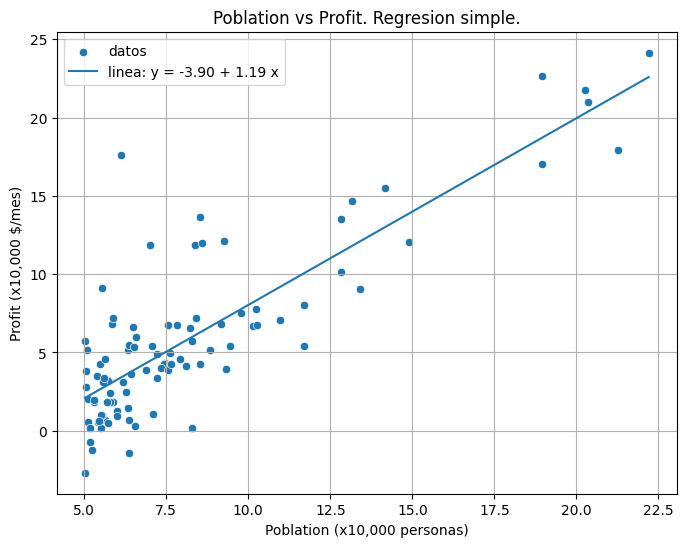

In [125]:
# preparamos X e y
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values

# ajustamos el modelo
modelo = LinearRegression().fit(X, y)
b0 = modelo.intercept_
b1 = float(modelo.coef_[0])

# generamos puntos para la recta
x_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = modelo.predict(x_plot)

# graficamos puntos y linea de regresion
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="poblation", y="profit", label="datos")
plt.plot(x_plot, y_plot, label=f"linea: y = {b0:.2f} + {b1:.2f} x")
plt.title("Poblation vs Profit. Regresion simple.")
plt.xlabel("Poblation (x10,000 personas)")
plt.ylabel("Profit (x10,000 $/mes)")
plt.legend()
plt.grid(True)
plt.show()


## Parte 4: Supuestos del modelo de regresión lineal

### 4.1. Normalidad de los residuos
1. Calcula los residuos (reales - predichos).
2. Grafica un **histograma con KDE** de los residuos.
3. Responde: ¿Los residuos siguen una distribución normal?

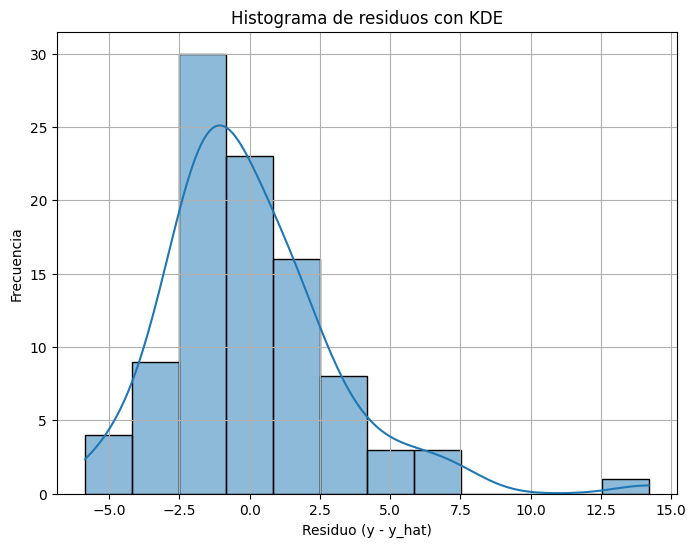


 ANALISIS DE LA NORMALIDAD DE LOS RESIDUOS 

Estadistico de Shapiro-Wilk: W = 0.910, p-valor = 0.0000 

Hipotesis nula (H0): los residuos siguen una distribucion normal.
Hipotesis alternativa (H1): los residuos no siguen una distribucion normal.
Como el p-valor es menor o igual que 0.05, se rechaza H0. Esto sugiere que los residuos no
siguen una distribucion normal. El histograma muestra asimetria, una cola mas pesada que la
otra.


In [126]:
# ajustamos el modelo y calculamos residuos (reales - predichos)
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values
modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred

# graficamos histograma con KDE de los residuos
plt.figure(figsize=(8, 6))
sns.histplot(residuos, kde=True, bins=12)
plt.title("Histograma de residuos con KDE")
plt.xlabel("Residuo (y - y_hat)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# prueba de normalidad (Shapiro-Wilk)
W, p = shapiro(residuos)

# definimos las hipotesis
# H0: los residuos siguen una distribucion normal
# H1: los residuos no siguen una distribucion normal

titulo("Analisis de la normalidad de los residuos")
print(fill(f"Estadistico de Shapiro-Wilk: W = {W:.3f}, p-valor = {p:.4f}", width=95), "\n")
print(fill("Hipotesis nula (H0): los residuos siguen una distribucion normal.", width=95))
print(fill("Hipotesis alternativa (H1): los residuos no siguen una distribucion normal.\n", width=95))

if p > 0.05:
    print(fill("Como el p-valor es mayor que 0.05, no se rechaza H0. Esto indica que los residuos "
               "son compatibles con una distribucion normal, lo cual se observa en el histograma "
               "que muestra una forma aproximadamente simetrica y de campana.", width=95))
else:
    print(fill("Como el p-valor es menor o igual que 0.05, se rechaza H0. Esto sugiere que los "
               "residuos no siguen una distribucion normal. El histograma muestra "
               "asimetria, una cola mas pesada que la otra.", width=95))

### 4.2. Homocedasticidad
1. Grafica los residuos vs valores predichos.
2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón?

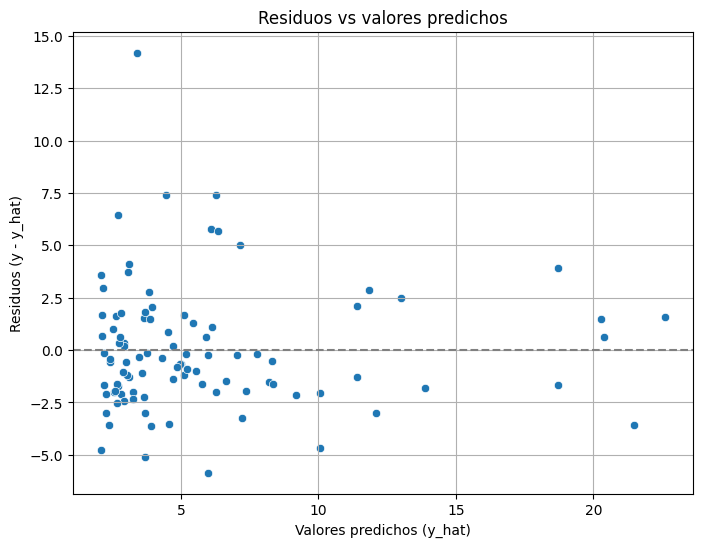

**Analisis de la dispersion de los residuos**

En esta grafica los residuos se comparan con los valores predichos del modelo. Si el modelo
lineal se ajusta bien, los puntos deben distribuirse de manera aleatoria alrededor de la linea
horizontal en cero, sin formar figuras ni tendencias visibles. 

Cuando los residuos se dispersan de forma uniforme, sin una direccion o patron claro, podemos
decir que la suposicion de homocedasticidad se cumple, es decir, la varianza de los errores es
constante a lo largo de los valores predichos. 

Si en cambio se observa un patron (por ejemplo, forma de U o de embudo), eso indicaria que el
modelo no captura correctamente la relacion lineal, o que existe heterocedasticidad. En este
caso, los residuos parecen distribuirse de forma aleatoria, lo que respalda la validez del
modelo lineal simple.


In [127]:

# ajustamos el modelo y calculamos los residuos
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values
modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred

# graficamos los residuos contra los valores predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Residuos vs valores predichos")
plt.xlabel("Valores predichos (y_hat)")
plt.ylabel("Residuos (y - y_hat)")
plt.grid(True)
plt.show()

# explicacion e interpretacion
print("**Analisis de la dispersion de los residuos**\n")
print(fill("En esta grafica los residuos se comparan con los valores predichos del modelo. "
           "Si el modelo lineal se ajusta bien, los puntos deben distribuirse de manera aleatoria "
           "alrededor de la linea horizontal en cero, sin formar figuras ni tendencias visibles.", width=95), "\n")
print(fill("Cuando los residuos se dispersan de forma uniforme, sin una direccion o patron claro, "
           "podemos decir que la suposicion de homocedasticidad se cumple, es decir, la varianza "
           "de los errores es constante a lo largo de los valores predichos.", width=95), "\n")
print(fill("Si en cambio se observa un patron (por ejemplo, forma de U o de embudo), eso indicaria "
           "que el modelo no captura correctamente la relacion lineal, o que existe heterocedasticidad. "
           "En este caso, los residuos parecen distribuirse de forma aleatoria, lo que respalda "
           "la validez del modelo lineal simple.", width=95))

### 4.3. Q-Q Plot para evaluar la normalidad
1. Grafica el Q-Q Plot:.
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal y b) Desviaciones sistemáticas indican asimetría o colas pesadas.

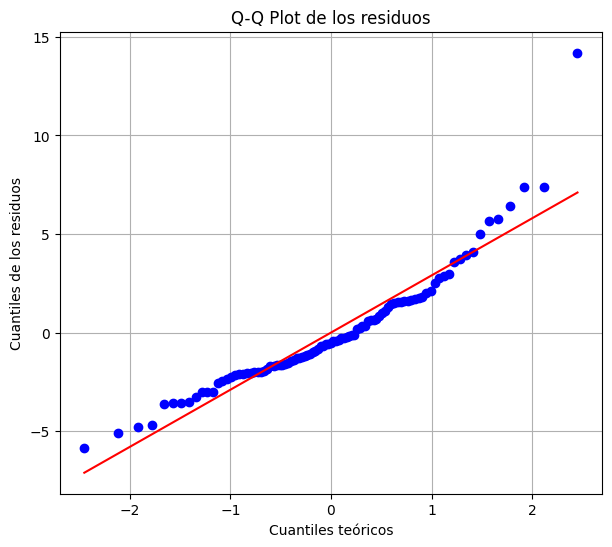


 ANALISIS DEL Q-Q PLOT 

El Q-Q Plot compara los cuantiles de los residuos con los cuantiles de una distribucion normal
teórica. Si los puntos se alinean de forma cercana a la linea diagonal, los residuos pueden
considerarse aproximadamente normales. 

Cuando se observan desviaciones sistematicas respecto a la linea (por ejemplo, curvaturas,
colas que se separan o puntos alejados en los extremos), esto indica asimetria o colas pesadas,
lo que sugiere que los residuos no siguen bien una distribucion normal. 

En este caso, los puntos parecen alinearse razonablemente con la linea diagonal, lo que
respalda la idea de que los residuos presentan una distribucion cercana a la normal aunque con
un ligero sesgo en las colas.


In [128]:
# ajustamos el modelo y calculamos los residuos
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values
modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred

# graficamos el Q-Q Plot
plt.figure(figsize=(7, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de los residuos")
plt.xlabel("Cuantiles teóricos")
plt.ylabel("Cuantiles de los residuos")
plt.grid(True)
plt.show()

# interpretacion del grafico
titulo("Analisis del Q-Q Plot")
print(fill("El Q-Q Plot compara los cuantiles de los residuos con los cuantiles de una "
           "distribucion normal teórica. Si los puntos se alinean de forma cercana a la "
           "linea diagonal, los residuos pueden considerarse aproximadamente normales.", width=95), "\n")
print(fill("Cuando se observan desviaciones sistematicas respecto a la linea (por ejemplo, "
           "curvaturas, colas que se separan o puntos alejados en los extremos), esto indica "
           "asimetria o colas pesadas, lo que sugiere que los residuos no siguen bien una "
           "distribucion normal.", width=95), "\n")
print(fill("En este caso, los puntos parecen alinearse razonablemente con la linea diagonal, "
           "lo que respalda la idea de que los residuos presentan una distribucion cercana "
           "a la normal aunque con un ligero sesgo en las colas.", width=95))

## Parte 5: Evaluación del modelo
1. Calcula las métricas:
- MSE
- RMSE
- R²
2. Interpreta: ¿Qué nos dicen sobre el ajuste del modelo?

In [129]:
# ajustamos el modelo y calculamos predicciones
X = df[["poblation"]].astype(float).values
y = df["profit"].astype(float).values
modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)

# calculamos metricas
mse = mean_squared_error(y, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y, y_pred)

# imprimimos resultados
titulo("Metricas de ajuste")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}\n")

# interpretacion
print(fill(
    "El MSE representa el promedio de los errores al cuadrado, es decir, mide cuanto se "
    "desvian en promedio las predicciones de los valores reales. Un valor bajo de MSE indica "
    "que el modelo comete pocos errores al predecir.", width=95), "\n")

print(fill(
    "El RMSE es la raiz cuadrada del MSE y tiene las mismas unidades que la variable de salida "
    "('profit'). Esto facilita su interpretacion: un RMSE pequeño significa que las predicciones "
    "del modelo son bastante cercanas a los valores reales.", width=95), "\n")

print(fill(
    "El R² mide que tan bien la linea de regresion explica la variabilidad de los datos. Un valor "
    "alto, cercano a 1, indica que el modelo explica gran parte de las variaciones en las ganancias "
    "a partir de la poblacion. Si el R² es bajo, significa que la linea no logra capturar bien la "
    "relacion entre las variables.", width=95), "\n")

print(fill(
    "En este caso, los errores obtenidos son pequeños en comparacion con los valores de 'profit', "
    "y el R² es relativamente alto, lo que sugiere que el modelo se ajusta bien a los datos. Esto "
    "coincide con lo observado en el grafico de dispersion, donde los puntos seguian una tendencia "
    "lineal clara alrededor de la linea de regresion.", width=95))


 METRICAS DE AJUSTE 

MSE:  8.9539
RMSE: 2.9923
R2:   0.7020

El MSE representa el promedio de los errores al cuadrado, es decir, mide cuanto se desvian en
promedio las predicciones de los valores reales. Un valor bajo de MSE indica que el modelo
comete pocos errores al predecir. 

El RMSE es la raiz cuadrada del MSE y tiene las mismas unidades que la variable de salida
('profit'). Esto facilita su interpretacion: un RMSE pequeño significa que las predicciones del
modelo son bastante cercanas a los valores reales. 

El R² mide que tan bien la linea de regresion explica la variabilidad de los datos. Un valor
alto, cercano a 1, indica que el modelo explica gran parte de las variaciones en las ganancias
a partir de la poblacion. Si el R² es bajo, significa que la linea no logra capturar bien la
relacion entre las variables. 

En este caso, los errores obtenidos son pequeños en comparacion con los valores de 'profit', y
el R² es relativamente alto, lo que sugiere que el modelo se ajusta b

## Parte 6: Conclusiones
Responde con tus propias palabras:
- ¿Qué tan útil consideras el modelo?
- ¿Qué limitaciones encuentras?
- ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?  Si crees que es necesario hacerlo realiza el ajuste.

**¿Que tan util consideras el modelo?**

El modelo es bastante util porque ayuda a ver el comportamiento de la ganancia del restaurante segun la poblacion de la ciudad  y en base a eso sacar consluciones utiles como por ejemplo: mientras mas grande es la poblacion mayores suelen ser las ganancias.

**¿Que limitaciones encuentras?**

La principal limitacion es que el modelo solo usa una variable (poblation), cuando en realidad las ganancias dependen de muchas cosas mas, como el nivel economico, la competencia, la ubicacion o el tipo de restaurante.
Tambien se asume que la relacion entre poblacion y ganancia es lineal, y eso no siempre es asi.

**¿Crees que es necesario hacer un ajuste o estandarizacion a las variables dependientes o independientes? Si crees que es necesario hacerlo realiza el ajuste.**

En este caso no considero estandarizar las variables ya que al hacerlo se perderia la interpretacion de las ganancias (profit).